In [7]:
import warnings
import os
import seaborn as sns

from mfsindy.cases.burgers import BurgersConfig, run_burgers_experiment
from mfsindy.plots import bubble_hist
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white", font_scale=1.1)

cfg = BurgersConfig(
        L=8.0,
        NX=256,
        t0=0.0,
        t1=10.0,
        dt=1e-2,
        nu=0.1,
        noise_level=0.25,
        poly_degree=1,
        derivative_order=2,
        H_xt=None,
        K=100,
        include_bias=True,
        stlsq_threshold=0.05,
        n_ensemble_models=100,
        n_runs=100,
        seed_base=0,
        results_dir="results",
        results_filename="burgers_weighted_errors.csv",
    )


1D Burgers with heteroscedastic noise and weak SINDy + GLS.

- simulates 1D viscous Burgers trajectories on a periodic domain
- adds heteroscedastic Gaussian noise with variance ∝ |u_x|
- fits three ensemble weak SINDy models:
    * No weighting (standard WeakPDELibrary)
    * Variance GLS (WeightedWeakPDELibrary with variance weights)
    * Ones GLS (WeightedWeakPDELibrary with all-ones weights)
- runs a Monte Carlo over random initial conditions to estimate:
    * relative L1 error on coefficients
    * L0 (support) mismatch
- saves the errors to disk and visualises their distributions
  with 1D bubble histograms.


In [5]:
print(
    f"Running Burgers GLS experiment with {cfg.n_runs} runs, "
    f"NX={cfg.NX}, dt={cfg.dt}, nu={cfg.nu}, "
    f"noise_level={cfg.noise_level}."
)

df_errors, L1_errors, L0_errors = run_burgers_experiment(cfg)


Running Burgers GLS experiment with 100 runs, NX=256, dt=0.01, nu=0.1, noise_level=0.25.


Monte Carlo Burgers GLS: 100%|██████████| 100/100 [01:23<00:00,  1.19it/s]


In [8]:
errors_path = os.path.join(cfg.results_dir, cfg.results_filename)
df_errors = pd.read_csv(errors_path)

methods = ["No weighting", "Variance GLS", "Ones GLS"]

L1_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L1")
    ]["value"].to_numpy()
    for m in methods
}
L0_errors = {
    m: df_errors[
        (df_errors["method"] == m) & (df_errors["metric"] == "L0")
    ]["value"].to_numpy()
    for m in methods
}

print("\nL1 errors (first few):")
for m in methods:
    print(m, np.median(L1_errors[m]))

print("\nL0 support errors (first few):")
for m in methods:
    print(m, np.median(L0_errors[m]))



L1 errors (first few):
No weighting 0.21424268485048034
Variance GLS 0.0031822074135244996
Ones GLS 0.00783338414768635

L0 support errors (first few):
No weighting 1.5
Variance GLS 0.0
Ones GLS 0.0


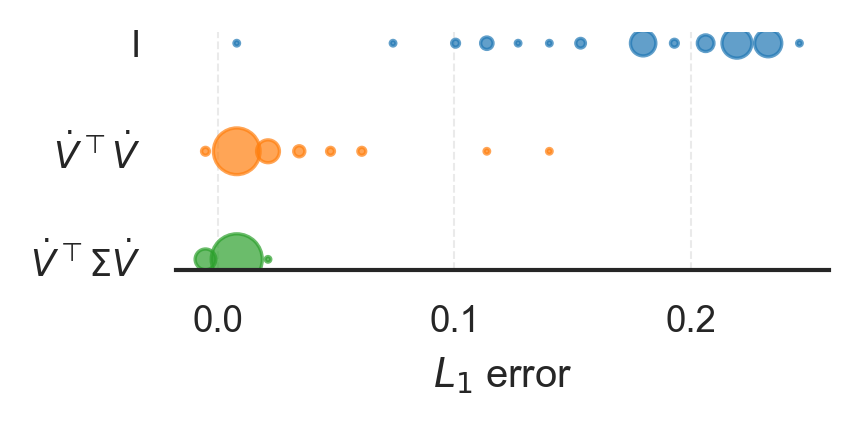

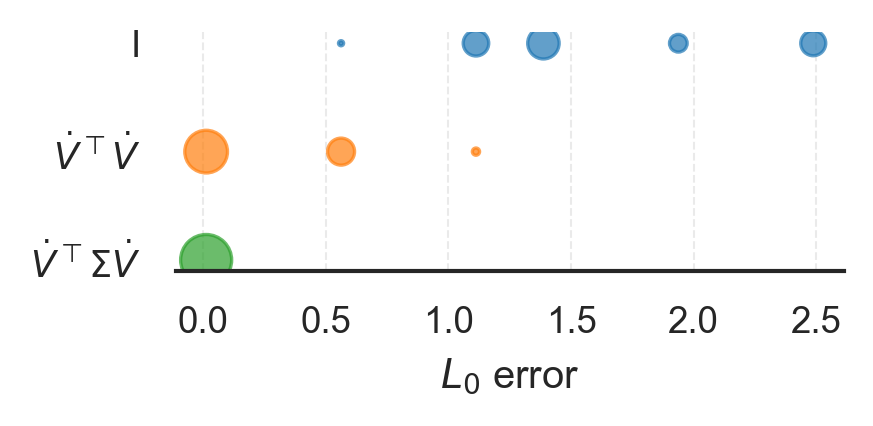

In [10]:
method_colors = {
    "No weighting": "tab:blue",
    "Variance GLS": "tab:green",
    "Ones GLS": "tab:orange",
}
methods = ["Variance GLS", "Ones GLS", "No weighting"]
labels = [r"$\dot{V}^\top\Sigma\dot{V}$",r"$\dot{V}^\top\dot{V}$","I"]

bubble_hist(
    errors_dict=L1_errors,
    xlabel=r"$L_1$ error",
    n_bins=20,
    models_order=methods,
    colors=method_colors,
    labels=labels
)

bubble_hist(
    errors_dict=L0_errors,
    xlabel=r"$L_0$ error",
    n_bins=10,
    models_order=methods,
    colors=method_colors,
    labels=labels
)
